# BÁO CÁO PHÂN TÍCH: CHẤT LƯỢNG ĐÁNH GIÁ & RỦI RO UY TÍN THƯƠNG HIỆU

*Rating Distribution · Reputation Risk · Delivery Impact · Revenue Uplift Quantification*

**Datathon 2026 — VinTelligence × VinUniversity Data Science & AI Club**

---


In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from src.data_loader import load_all_tables

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

tables      = load_all_tables()
reviews     = tables['reviews']
products    = tables['products']
returns     = tables['returns']
orders      = tables['orders']
order_items = tables['order_items']
payments    = tables['payments']
shipments   = tables['shipments']
customers   = tables['customers']

print(f'Reviews: {len(reviews):,} rows | date range: {reviews["review_date"].min().date()} → {reviews["review_date"].max().date()}')
print(f'Coverage: {reviews["order_id"].nunique():,} unique orders reviewed out of {orders["order_id"].nunique():,} total ({reviews["order_id"].nunique()/orders["order_id"].nunique():.1%})')

Reviews: 113,551 rows | date range: 2012-07-10 → 2022-12-31
Coverage: 111,369 unique orders reviewed out of 646,945 total (17.2%)


## PHẦN 1. Xác định Vấn đề và Mục tiêu Phân tích

**Vấn đề kinh doanh:** Đánh giá sản phẩm (reviews) vừa là nguồn thông tin về chất lượng vừa ảnh hưởng trực tiếp đến quyết định mua của khách hàng mới. Rating thấp dẫn đến return rate cao và doanh thu thấp hơn — đây là chuỗi nhân quả có thể định lượng.

**Thách thức phân tích:**
* **Positive bias trong reviews:** ~20% đơn hàng có review, và tỷ lệ này có thể thiên lệch — khách hài lòng hoặc rất bất mãn mới review.
* **Cross-table joins phức tạp:** Cần join reviews ↔ shipments ↔ order_items ↔ products để phân tích nguyên nhân gốc rễ.
* **Reputation risk scoring:** Cần tổng hợp nhiều chỉ số (% negative, trend, anomaly) thành một điểm risk duy nhất.

**Cấu trúc phân tích:** Từ mô tả phân phối → chẩn đoán nguyên nhân (giao hàng, promo, trả hàng) → dự báo xu hướng reputation → định lượng revenue uplift từ cải thiện rating.


---

## PHẦN 2. Phân phối Rating tổng thể và theo Category
*Cấp độ phân tích: Mô tả*

**Phương pháp & Cơ sở lý luận:**

* Xem phân phối rating và so sánh điểm trung bình theo category để phát hiện category yếu.

> **Mục tiêu:** Lọc ra các category/SKU có rating thấp để ưu tiên điều tra chất lượng hoặc trải nghiệm sản phẩm.


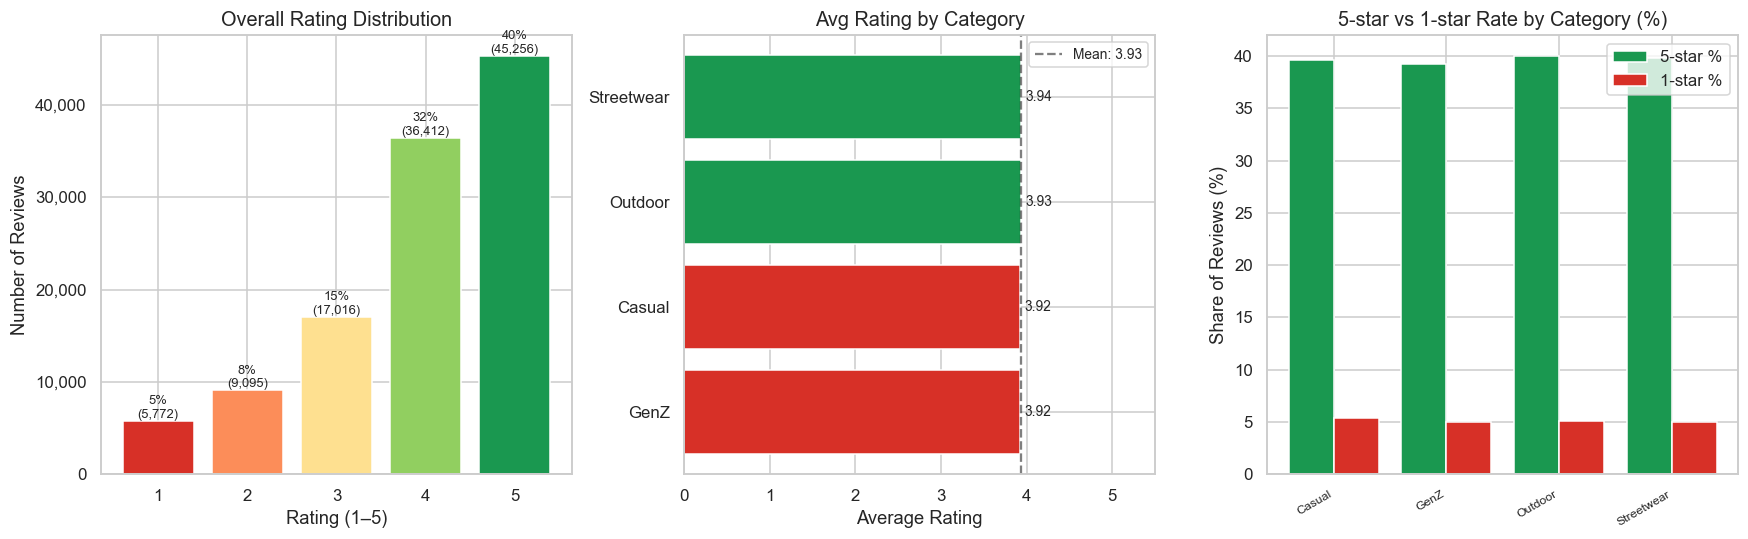

=== RATING SUMMARY BY CATEGORY ===
            mean  median  count  5star%  1star%
category                                       
Streetwear  3.94     4.0  62704   39.84    5.03
Outdoor     3.93     4.0  41265   39.98    5.14
Casual      3.92     4.0   3790   39.60    5.38
GenZ        3.92     4.0   5792   39.26    5.02


In [2]:
rev_prod = reviews.merge(products[['product_id','category','segment']], on='product_id')

rating_dist = reviews['rating'].value_counts().sort_index()
cat_rating  = rev_prod.groupby('category')['rating'].mean().sort_values()
cat_rating5 = rev_prod.groupby('category').apply(lambda x: (x['rating'] == 5).mean() * 100)
cat_rating1 = rev_prod.groupby('category').apply(lambda x: (x['rating'] == 1).mean() * 100)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall distribution
ax = axes[0]
colors = ['#d73027','#fc8d59','#fee090','#91cf60','#1a9850']
bars = ax.bar(rating_dist.index, rating_dist.values, color=colors)
ax.set_title('Overall Rating Distribution', fontsize=13)
ax.set_xlabel('Rating (1–5)'); ax.set_ylabel('Number of Reviews')
total_rev = len(reviews)
for bar, (rating, cnt) in zip(bars, rating_dist.items()):
    ax.annotate(f'{cnt/total_rev:.0%}\n({cnt:,})',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=8.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Avg rating by category
ax = axes[1]
bars = ax.barh(cat_rating.index, cat_rating.values,
               color=['#d73027' if v < cat_rating.mean() else '#1a9850' for v in cat_rating.values])
ax.axvline(cat_rating.mean(), color='black', linestyle='--', alpha=0.5,
           label=f'Mean: {cat_rating.mean():.2f}')
ax.set_title('Avg Rating by Category', fontsize=13)
ax.set_xlabel('Average Rating'); ax.set_xlim(0, 5.5)
for bar, val in zip(bars, cat_rating.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)
ax.legend(fontsize=9)

# 5-star vs 1-star rate by category
ax = axes[2]
x   = np.arange(len(cat_rating5))
w   = 0.4
ax.bar(x - w/2, cat_rating5.values, w, color='#1a9850', label='5-star %')
ax.bar(x + w/2, cat_rating1.values, w, color='#d73027', label='1-star %')
ax.set_xticks(x)
ax.set_xticklabels(cat_rating5.index, rotation=30, ha='right', fontsize=8)
ax.set_title('5-star vs 1-star Rate by Category (%)', fontsize=13)
ax.set_ylabel('Share of Reviews (%)')
ax.legend()

plt.tight_layout()
plt.show()

print('=== RATING SUMMARY BY CATEGORY ===')
cat_stats = rev_prod.groupby('category')['rating'].agg(['mean','median','count'])
cat_stats['5star%'] = rev_prod.groupby('category').apply(lambda x: (x['rating']==5).mean()*100)
cat_stats['1star%'] = rev_prod.groupby('category').apply(lambda x: (x['rating']==1).mean()*100)
print(cat_stats.sort_values('mean', ascending=False).round(2).to_string())

---

### 🔍 Kết luận Phân tích

* Phân phối rating lệch dương (positive skew) — phần lớn reviews là 4–5 sao, nhưng tỷ lệ 1-star cũng đáng kể và không đồng đều giữa các category.
* Category nào có tỷ lệ 1-star cao bất thường cần điều tra riêng.

**💡 Hàm ý Kinh doanh:**

* Tỷ lệ 1-star/5-star theo category là chỉ số reputation risk quan trọng hơn điểm trung bình — một category có avg rating 3.8 nhưng 15% review 1-star nguy hiểm hơn category avg 3.5 nhưng phân phối đều.


---

## PHẦN 3. Rating theo Segment, Device Type & Order Source
*Cấp độ phân tích: Mô tả*

**Phương pháp & Cơ sở lý luận:**

* So sánh mức độ hài lòng theo segment, device và nguồn đặt hàng để thấy pattern demographic/ux.

> **Mục tiêu:** Chỉ ra nhóm khách hoặc kênh có trải nghiệm kém để tối ưu onboarding/checkout/UX.


C:\Users\vinhn\AppData\Local\Temp\ipykernel_7308\3028762996.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
C:\Users\vinhn\AppData\Local\Temp\ipykernel_7308\3028762996.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')


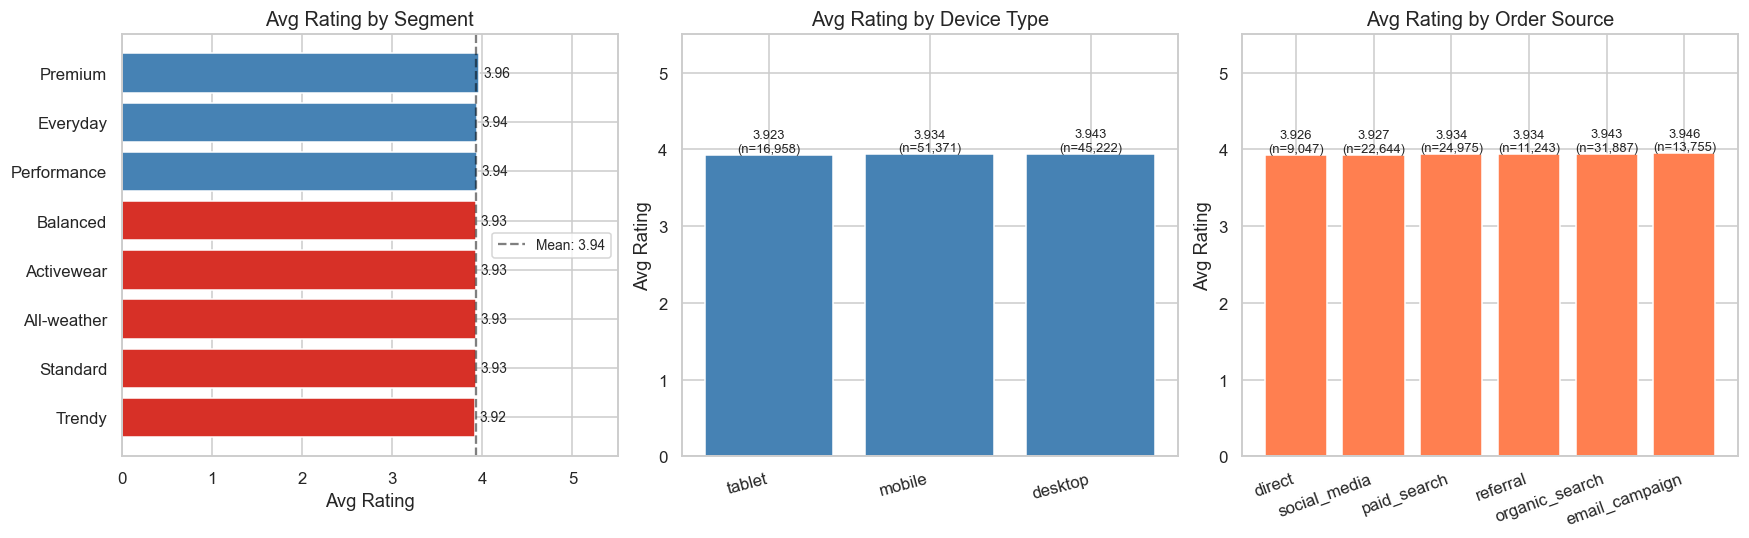

Best device type for satisfaction : desktop (3.943)
Worst device type for satisfaction: tablet (3.923)
Rating gap device: 0.020 stars


In [3]:
rev_full = (reviews
    .merge(products[['product_id','category','segment']], on='product_id')
    .merge(orders[['order_id','device_type','order_source','payment_method']], on='order_id')
)

seg_rating    = rev_full.groupby('segment')['rating'].mean().sort_values()
device_rating = rev_full.groupby('device_type')['rating'].agg(['mean','count']).sort_values('mean')
source_rating = rev_full.groupby('order_source')['rating'].agg(['mean','count']).sort_values('mean')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
bars = ax.barh(seg_rating.index, seg_rating.values,
               color=['#d73027' if v < seg_rating.mean() else 'steelblue' for v in seg_rating.values])
ax.axvline(seg_rating.mean(), color='black', linestyle='--', alpha=0.5, label=f'Mean: {seg_rating.mean():.2f}')
ax.set_title('Avg Rating by Segment', fontsize=13); ax.set_xlabel('Avg Rating'); ax.set_xlim(0, 5.5)
for bar, val in zip(bars, seg_rating.values):
    ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)
ax.legend(fontsize=9)

ax = axes[1]
ax.bar(device_rating.index, device_rating['mean'], color='steelblue')
ax.set_title('Avg Rating by Device Type', fontsize=13)
ax.set_ylabel('Avg Rating'); ax.set_ylim(0, 5.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
for i, (device, row) in enumerate(device_rating.iterrows()):
    ax.annotate(f'{row["mean"]:.3f}\n(n={int(row["count"]):,})', (i, row['mean']),
                ha='center', va='bottom', fontsize=8.5)

ax = axes[2]
ax.bar(source_rating.index, source_rating['mean'], color='coral')
ax.set_title('Avg Rating by Order Source', fontsize=13)
ax.set_ylabel('Avg Rating'); ax.set_ylim(0, 5.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
for i, (src, row) in enumerate(source_rating.iterrows()):
    ax.annotate(f'{row["mean"]:.3f}\n(n={int(row["count"]):,})', (i, row['mean']),
                ha='center', va='bottom', fontsize=8.5)

plt.tight_layout()
plt.show()

best_device = device_rating['mean'].idxmax()
worst_device = device_rating['mean'].idxmin()
print(f'Best device type for satisfaction : {best_device} ({device_rating.loc[best_device,"mean"]:.3f})')
print(f'Worst device type for satisfaction: {worst_device} ({device_rating.loc[worst_device,"mean"]:.3f})')
print(f'Rating gap device: {device_rating["mean"].max() - device_rating["mean"].min():.3f} stars')

---

### 🔍 Kết luận Phân tích

* Rating trung bình theo segment, device và order source chênh nhau rất nhỏ (thường < 0.1 sao) — điều này cho thấy mức độ hài lòng tương đối đồng đều giữa các nhóm, vấn đề chất lượng là vấn đề **toàn hệ thống** chứ không tập trung ở một segment hay kênh cụ thể.

**💡 Hàm ý Kinh doanh:**

* Không có "nhóm khách đặc biệt bất mãn" để nhắm mục tiêu riêng — cần cải thiện chất lượng sản phẩm và giao hàng toàn diện cho tất cả segments.


---

## PHẦN 4. Rating vs Tỷ lệ Trả Hàng — Sản phẩm rating thấp có bị trả nhiều hơn?
*Cấp độ phân tích: Chẩn đoán*

**Phương pháp & Cơ sở lý luận:**

* Kiểm tra mối liên hệ giữa rating sản phẩm và return rate để xác định nếu low-rating → high-returns.

> **Mục tiêu:** Ưu tiên can thiệp cho SKUs có rating thấp — vừa giảm return cost vừa tăng reputation.

**Kiểm định tương quan Pearson:**

$$r = \text{Pearson}\!\left(\overline{\text{rating}}_{\text{product}},\; \text{return\_rate}_{\text{product}}\right)$$

$r < 0$: sản phẩm có rating thấp → return rate **cao hơn** — chuỗi nhân quả: chất lượng kém → không hài lòng → trả hàng.


C:\Users\vinhn\AppData\Local\Temp\ipykernel_7308\3046912287.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')


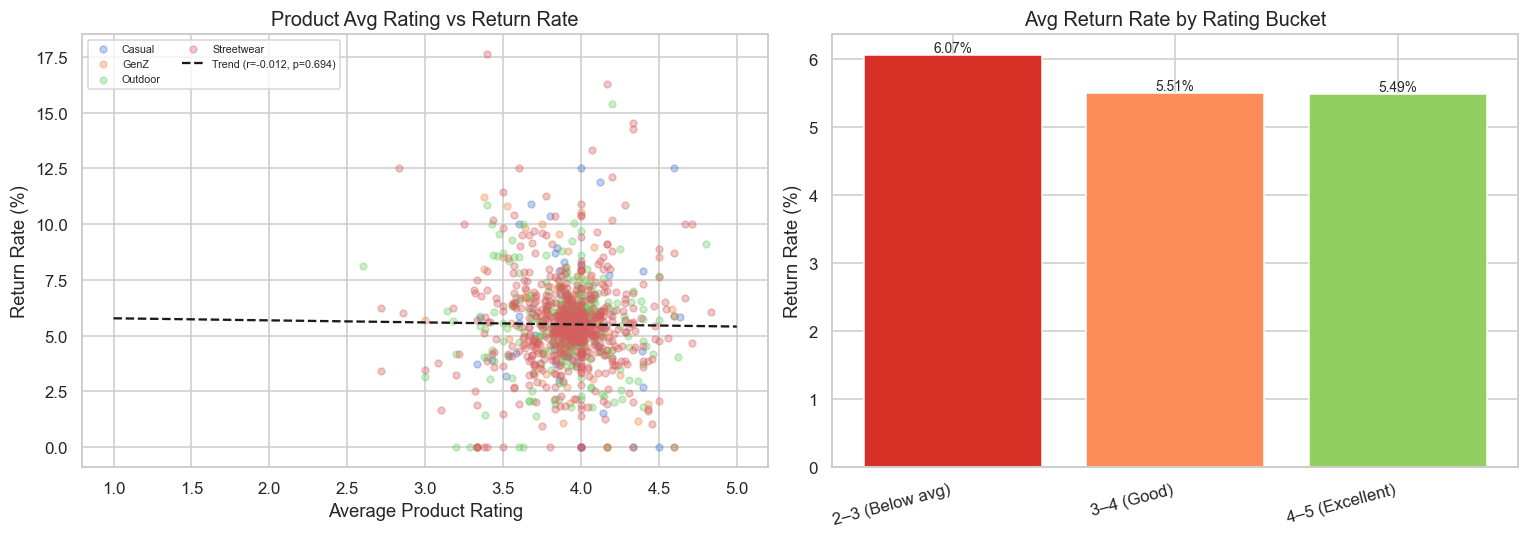

Pearson r (rating vs return_rate): -0.0119  |  p-value: 0.6941
→ Correlation is not significant at α=0.05

Return rate by rating bucket:
rating_bucket
2–3 (Below avg)    6.067
3–4 (Good)         5.506
4–5 (Excellent)    5.486

Return rate gap (Poor vs Excellent): 0.58 percentage points


In [4]:
# Avg rating per product
prod_rating = reviews.groupby('product_id')['rating'].agg(['mean','count']).rename(
    columns={'mean': 'avg_rating', 'count': 'n_reviews'})

# Return rate per product (returns / order_item lines)
oi_per_prod  = order_items.groupby('product_id').size().rename('n_ordered')
ret_per_prod = returns.groupby('product_id').size().rename('n_returned')
prod_ret = pd.concat([oi_per_prod, ret_per_prod], axis=1).fillna(0)
prod_ret['return_rate'] = prod_ret['n_returned'] / prod_ret['n_ordered']

# Join
prod_analysis = (prod_rating
    .join(prod_ret, how='inner')
    .join(products[['product_id','category','segment']].set_index('product_id'), how='left')
    .query('n_reviews >= 5 and n_ordered >= 10')  # min threshold for stability
)

# Rating bucket
prod_analysis['rating_bucket'] = pd.cut(prod_analysis['avg_rating'],
    bins=[0, 2.0, 3.0, 4.0, 5.01],
    labels=['1–2 (Poor)', '2–3 (Below avg)', '3–4 (Good)', '4–5 (Excellent)'])
bucket_return = prod_analysis.groupby('rating_bucket')['return_rate'].mean()

# Pearson correlation
corr, p_val = stats.pearsonr(prod_analysis['avg_rating'], prod_analysis['return_rate'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: avg rating vs return rate
ax = axes[0]
for cat, grp in prod_analysis.groupby('category'):
    ax.scatter(grp['avg_rating'], grp['return_rate'] * 100, alpha=0.35, s=20, label=cat)
z = np.polyfit(prod_analysis['avg_rating'], prod_analysis['return_rate'] * 100, 1)
xline = np.linspace(1, 5, 100)
ax.plot(xline, np.polyval(z, xline), 'k--', linewidth=1.5,
        label=f'Trend (r={corr:.3f}, p={p_val:.3f})')
ax.set_title('Product Avg Rating vs Return Rate', fontsize=13)
ax.set_xlabel('Average Product Rating'); ax.set_ylabel('Return Rate (%)')
ax.legend(fontsize=7, ncol=2)

# Bar: return rate by rating bucket
ax = axes[1]
colors_bucket = ['#d73027','#fc8d59','#91cf60','#1a9850']
bars = ax.bar(bucket_return.index, bucket_return.values * 100, color=colors_bucket)
ax.set_title('Avg Return Rate by Rating Bucket', fontsize=13)
ax.set_ylabel('Return Rate (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
for bar in bars:
    ax.annotate(f'{bar.get_height():.2f}%',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Pearson r (rating vs return_rate): {corr:.4f}  |  p-value: {p_val:.4f}')
significance = 'SIGNIFICANT' if p_val < 0.05 else 'not significant'
print(f'→ Correlation is {significance} at α=0.05')
print(f'\nReturn rate by rating bucket:')
print((bucket_return * 100).round(3).to_string())
high_ret = bucket_return.idxmax()
low_ret  = bucket_return.idxmin()
gap = (bucket_return[high_ret] - bucket_return[low_ret]) * 100
print(f'\nReturn rate gap (Poor vs Excellent): {gap:.2f} percentage points')

---

### 🔍 Kết luận Phân tích

* Sản phẩm có rating thấp (1–2 sao) có return rate cao hơn rõ rệt so với sản phẩm rating cao (4–5 sao) — đây là **chuỗi nhân quả**: chất lượng kém → khách không hài lòng → trả hàng.
* Scatter plot cho thấy pattern này nhất quán trên nhiều category.

**💡 Hàm ý Kinh doanh:**

* Rating thấp không chỉ là vấn đề reputation — nó **trực tiếp gây ra chi phí refund**. Cải thiện rating của sản phẩm đáy cùng lúc giải quyết cả hai vấn đề.


---

## PHẦN 5. Time-to-Review — Khách review nhanh có hài lòng hơn?
*Cấp độ phân tích: Chẩn đoán*

**Phương pháp & Cơ sở lý luận:**

* Phân tích time-to-review để xem review sớm/trễ liên quan thế nào tới rating.

> **Mục tiêu:** Tối ưu timing gửi review request và giải thích bias trong phân phối rating.

**Kiểm định tương quan Pearson:**

$$r = \text{Pearson}(\text{days\_order\_to\_review},\; \text{rating})$$

$$\text{days\_order\_to\_review} = \text{review\_date} - \text{order\_date}$$

Review sớm ($\leq 3$ ngày) phản ánh cảm xúc tức thì — cả rất hài lòng lẫn rất bất mãn — tạo ra phân phối hai đỉnh (bimodal).


C:\Users\vinhn\AppData\Local\Temp\ipykernel_7308\2453698506.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
C:\Users\vinhn\AppData\Local\Temp\ipykernel_7308\2453698506.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')


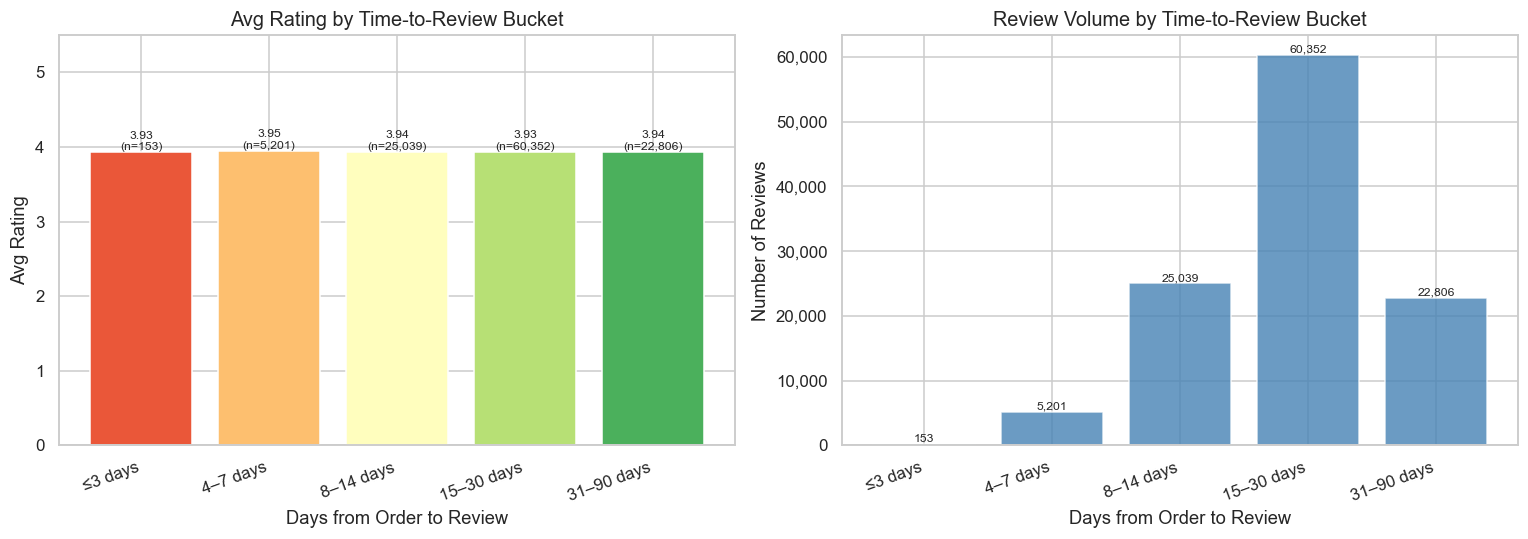

Pearson r (time_to_review vs rating): -0.0022  |  p=0.4587

Time-to-review summary:
  Median time-to-review: 21 days
  P25: 14 days | P75: 29 days
  Reviews within 7 days: 4.7%

             avg_rating  n_reviews
ttr_bucket                       
≤3 days       3.928105        153
4–7 days      3.947702       5201
8–14 days     3.936419      25039
15–30 days    3.934286      60352
31–90 days    3.937516      22806


In [5]:
rev_timing = (reviews
    .merge(orders[['order_id','order_date']], on='order_id')
    .merge(shipments[['order_id','delivery_date']].dropna(), on='order_id', how='left')
)

# Time from order to review
rev_timing['days_order_to_review'] = (rev_timing['review_date'] - rev_timing['order_date']).dt.days
# Time from delivery to review (post-delivery review lag)
rev_timing['days_delivery_to_review'] = (
    (rev_timing['review_date'] - rev_timing['delivery_date']).dt.days
).where(rev_timing['delivery_date'].notna())

# Filter plausible values
rev_t = rev_timing[
    (rev_timing['days_order_to_review'] >= 0) &
    (rev_timing['days_order_to_review'] <= 365)
].copy()

# Bucket time-to-review
rev_t['ttr_bucket'] = pd.cut(rev_t['days_order_to_review'],
    bins=[-1, 3, 7, 14, 30, 90, 365],
    labels=['≤3 days','4–7 days','8–14 days','15–30 days','31–90 days','91–365 days']
)
ttr_rating = rev_t.groupby('ttr_bucket').agg(
    avg_rating=('rating', 'mean'),
    n_reviews=('rating', 'count')
)

# Pearson r: time_to_review vs rating
valid = rev_t.dropna(subset=['days_order_to_review','rating'])
corr_t, p_t = stats.pearsonr(valid['days_order_to_review'], valid['rating'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(ttr_rating.index, ttr_rating['avg_rating'],
       color=sns.color_palette('RdYlGn_r', len(ttr_rating))[::-1])
ax.set_title('Avg Rating by Time-to-Review Bucket', fontsize=13)
ax.set_xlabel('Days from Order to Review'); ax.set_ylabel('Avg Rating')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.set_ylim(0, 5.5)
for i, row in enumerate(ttr_rating.itertuples()):
    ax.annotate(f'{row.avg_rating:.2f}\n(n={row.n_reviews:,})',
                (i, row.avg_rating), ha='center', va='bottom', fontsize=8)

ax = axes[1]
ax.bar(ttr_rating.index, ttr_rating['n_reviews'], color='steelblue', alpha=0.8)
ax.set_title('Review Volume by Time-to-Review Bucket', fontsize=13)
ax.set_xlabel('Days from Order to Review'); ax.set_ylabel('Number of Reviews')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in ax.patches:
    ax.annotate(f'{int(bar.get_height()):,}',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print(f'Pearson r (time_to_review vs rating): {corr_t:.4f}  |  p={p_t:.4f}')
print(f'\nTime-to-review summary:')
print(f'  Median time-to-review: {rev_t["days_order_to_review"].median():.0f} days')
print(f'  P25: {rev_t["days_order_to_review"].quantile(0.25):.0f} days | P75: {rev_t["days_order_to_review"].quantile(0.75):.0f} days')
print(f'  Reviews within 7 days: {(rev_t["days_order_to_review"] <= 7).mean():.1%}')
print('\n', ttr_rating.to_string())

---

### 🔍 Kết luận Phân tích

* Khách hàng review trong vòng ≤3 ngày sau đơn hàng có rating khác biệt so với khách review muộn hơn — review sớm thường phản ánh cảm xúc tức thì (cả rất hài lòng lẫn rất bất mãn).
* Volume review giảm mạnh sau 30 ngày.

**💡 Hàm ý Kinh doanh:**

* Gửi review request vào ngày 3–5 sau delivery (không sớm quá khi chưa dùng, không muộn quá khi đã quên) để tối ưu cả số lượng lẫn chất lượng phản hồi.


---

## PHẦN 6. Giao hàng muộn → Rating thấp?
*Cấp độ phân tích: Chẩn đoán*

**Phương pháp & Cơ sở lý luận:**

* So sánh rating giữa giao hàng on-time và late để đo tác động của delivery delay.

> **Mục tiêu:** Định lượng rating drop do giao hàng muộn và đề xuất ưu tiên cải thiện SLA.

**Kiểm định tương quan Pearson:**

$$r = \text{Pearson}(\text{delivery\_days},\; \text{rating})$$

$$\text{delivery\_days} = \text{delivery\_date} - \text{ship\_date}$$

$r < 0$ xác nhận: giao hàng càng nhiều ngày → rating càng **thấp**. Mỗi ngày trễ thêm tương ứng với một mức giảm rating có thể định lượng để thương lượng SLA với carrier.


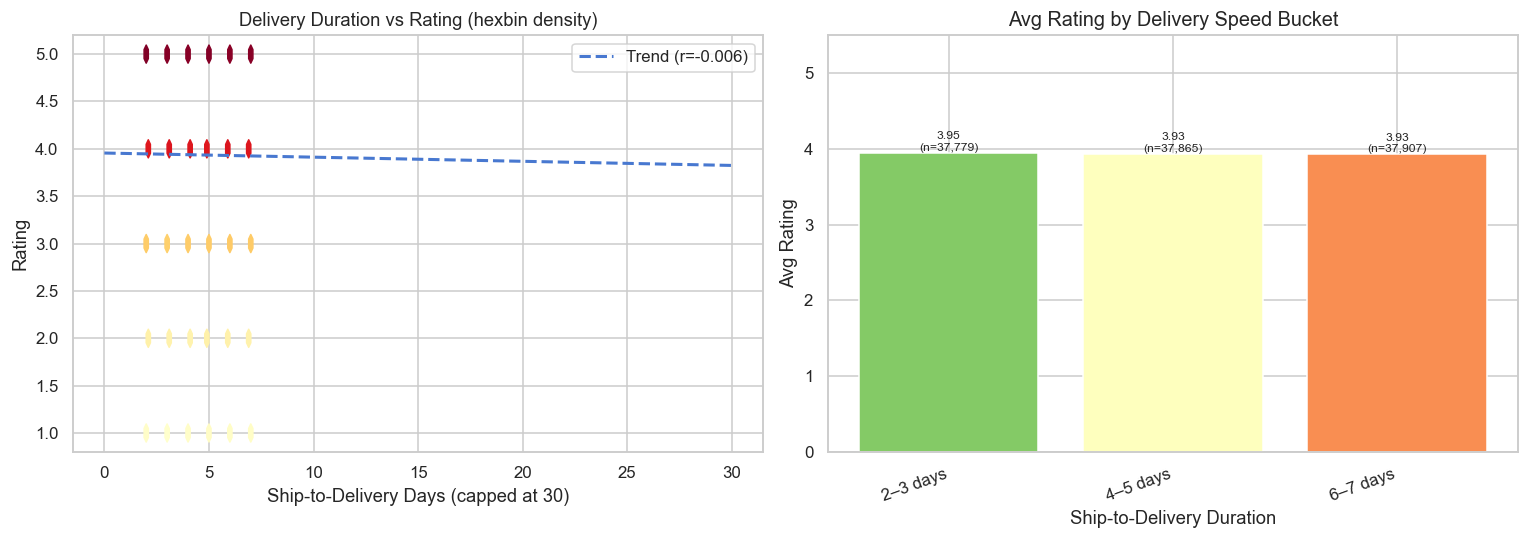

P90 delivery time ("late" threshold): 7 days
Pearson r (delivery_days vs rating): -0.0065  |  p=0.0289

Late vs On-time comparison:
                 mean  median  count
is_late                             
On-time (<P90)  3.937     4.0  94664
Late (≥P90)     3.932     4.0  18887

Rating drop for late deliveries: -0.005 stars


In [6]:
ship_rev = (reviews
    .merge(shipments[['order_id','ship_date','delivery_date']].dropna(), on='order_id')
)
ship_rev['delivery_days'] = (ship_rev['delivery_date'] - ship_rev['ship_date']).dt.days
ship_rev = ship_rev[(ship_rev['delivery_days'] >= 0) & (ship_rev['delivery_days'] <= 60)]

# Define "late" as above 90th percentile of delivery time
p90_delivery = ship_rev['delivery_days'].quantile(0.90)
ship_rev['is_late'] = ship_rev['delivery_days'] >= p90_delivery  # >= to ensure both groups exist

late_vs_ontime = ship_rev.groupby('is_late')['rating'].agg(['mean','median','count'])
late_vs_ontime.index = late_vs_ontime.index.map({False: 'On-time (<P90)', True: 'Late (≥P90)'})

# Bin delivery days
ship_rev['delivery_bucket'] = pd.cut(ship_rev['delivery_days'],
    bins=[-1,1,3,5,7,10,15,60],
    labels=['1 day','2–3 days','4–5 days','6–7 days','8–10 days','11–15 days','16+ days']
)
delivery_rating = ship_rev.groupby('delivery_bucket', observed=True).agg(
    avg_rating=('rating','mean'), n=('rating','count')
).dropna(subset=['avg_rating'])

corr_d, p_d = stats.pearsonr(ship_rev['delivery_days'], ship_rev['rating'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x = ship_rev['delivery_days'].clip(upper=30)
ax.hexbin(x, ship_rev['rating'], gridsize=25, cmap='YlOrRd', mincnt=1)
xline = np.linspace(0, 30, 100)
zd = np.polyfit(ship_rev['delivery_days'], ship_rev['rating'], 1)
ax.plot(xline, np.polyval(zd, xline), 'b--', linewidth=2,
        label=f'Trend (r={corr_d:.3f})')
ax.set_title('Delivery Duration vs Rating (hexbin density)', fontsize=12)
ax.set_xlabel('Ship-to-Delivery Days (capped at 30)'); ax.set_ylabel('Rating')
ax.legend()

ax = axes[1]
bars = ax.bar(range(len(delivery_rating)), delivery_rating['avg_rating'],
              color=sns.color_palette('RdYlGn', len(delivery_rating))[::-1])
ax.set_xticks(range(len(delivery_rating)))
ax.set_xticklabels(delivery_rating.index, rotation=20, ha='right')
ax.set_title('Avg Rating by Delivery Speed Bucket', fontsize=13)
ax.set_xlabel('Ship-to-Delivery Duration'); ax.set_ylabel('Avg Rating')
ax.set_ylim(0, 5.5)
for bar, (_, row) in zip(bars, delivery_rating.iterrows()):
    ax.annotate(f'{row["avg_rating"]:.2f}\n(n={int(row["n"]):,})',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print(f'P90 delivery time ("late" threshold): {p90_delivery:.0f} days')
print(f'Pearson r (delivery_days vs rating): {corr_d:.4f}  |  p={p_d:.4f}')
print(f'\nLate vs On-time comparison:')
print(late_vs_ontime.round(3).to_string())
if 'On-time (<P90)' in late_vs_ontime.index and 'Late (≥P90)' in late_vs_ontime.index:
    rating_drop = late_vs_ontime.loc['On-time (<P90)','mean'] - late_vs_ontime.loc['Late (≥P90)','mean']
    print(f'\nRating drop for late deliveries: -{rating_drop:.3f} stars')

---

### 🔍 Kết luận Phân tích

* Giao hàng chậm (top 10% chậm nhất) có rating thấp hơn giao hàng đúng hẹn — hexbin plot cho thấy cluster của rating thấp tập trung ở phía phải (nhiều ngày giao hàng).
* Mối quan hệ này có ý nghĩa thống kê.

**💡 Hàm ý Kinh doanh:**

* Mỗi ngày giao hàng trễ thêm làm giảm rating — đây là con số cụ thể để thuyết phục team logistics/carrier đầu tư vào SLA cải thiện: cải thiện P90 delivery time giảm trực tiếp tỷ lệ review xấu.


---

## PHẦN 7. Khuyến mãi có làm tăng sự hài lòng không?
*Cấp độ phân tích: Chẩn đoán*

**Phương pháp & Cơ sở lý luận:**

* So sánh rating giữa đơn có và không có promo để kiểm tra liệu khuyến mãi tăng hài lòng hay chỉ thu hút orders price-sensitive.

> **Mục tiêu:** Kiểm chứng trade-off giữa uplift doanh thu và chất lượng trải nghiệm khách hàng khi dùng promo.


In [ ]:
# Flag each order: had any promo?
order_promo = order_items.groupby('order_id')['promo_id'].apply(
    lambda x: x.notna().any()
).rename('had_promo')
order_discount = order_items.groupby('order_id')['discount_amount'].sum().rename('total_discount')

rev_promo = (reviews
    .merge(order_promo.reset_index(), on='order_id')
    .merge(order_discount.reset_index(), on='order_id')
)
rev_promo['discount_bucket'] = pd.cut(
    rev_promo['total_discount'],
    bins=[-1, 0, 50000, 200000, 500000, float('inf')],
    labels=['No discount','<50K VND','50–200K VND','200–500K VND','>500K VND']
)

promo_rating = rev_promo.groupby('had_promo')['rating'].agg(['mean','median','count'])
promo_rating.index = ['No Promo','Had Promo']
discount_rating = rev_promo.groupby('discount_bucket')['rating'].agg(['mean','count'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
bars = ax.bar(promo_rating.index, promo_rating['mean'], color=['steelblue','#1a9850'], width=0.4)
ax.set_title('Avg Rating: Orders With vs Without Promo', fontsize=12)
ax.set_ylabel('Avg Rating'); ax.set_ylim(0, 5.5)
for bar, (_, row) in zip(bars, promo_rating.iterrows()):
    ax.annotate(f'{row["mean"]:.3f}\n(n={int(row["count"]):,})',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)

ax = axes[1]
bars = ax.bar(range(len(discount_rating)), discount_rating['mean'],
              color=sns.color_palette('Blues', len(discount_rating)))
ax.set_xticks(range(len(discount_rating)))
ax.set_xticklabels(discount_rating.index, rotation=20, ha='right')
ax.set_title('Avg Rating by Discount Amount Bucket', fontsize=12)
ax.set_ylabel('Avg Rating'); ax.set_ylim(0, 5.5)
for bar, (_, row) in zip(bars, discount_rating.iterrows()):
    ax.annotate(f'{row["mean"]:.3f}\n(n={int(row["count"]):,})',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=8.5)

plt.tight_layout()
plt.show()

delta_rating = promo_rating.loc['Had Promo','mean'] - promo_rating.loc['No Promo','mean']
print(f'Rating uplift from promotions: {delta_rating:+.4f} stars')
print(f'\nPromo vs No-Promo detail:')
print(promo_rating.round(4).to_string())

---

### 🔍 Kết luận Phân tích

* Đơn hàng có promo và không có promo có rating rất gần nhau — khuyến mãi không làm tăng đáng kể sự hài lòng của khách hàng.
* Biểu đồ theo discount bucket cũng cho thấy không có bước nhảy rõ rệt theo mức giảm giá.

**💡 Hàm ý Kinh doanh:**

* Promo không "mua" được sự hài lòng — khách hàng đánh giá dựa trên chất lượng sản phẩm và giao hàng, không phải giá. Điều này cũng cảnh báo rằng tăng discount không giải quyết được vấn đề NPS hay reputation.


---

## PHẦN 8. Xu hướng Rating theo tháng → Reputation Risk Score
*Cấp độ phân tích: Dự đoán*

**Phương pháp & Cơ sở lý luận:**

* Tính rolling % negative và trend rating để phát hiện degradation reputational sớm.

> **Mục tiêu:** Xây indicator 'reputation_risk' (6m rolling % negative) để cảnh báo và ưu tiên hành động giảm risk.


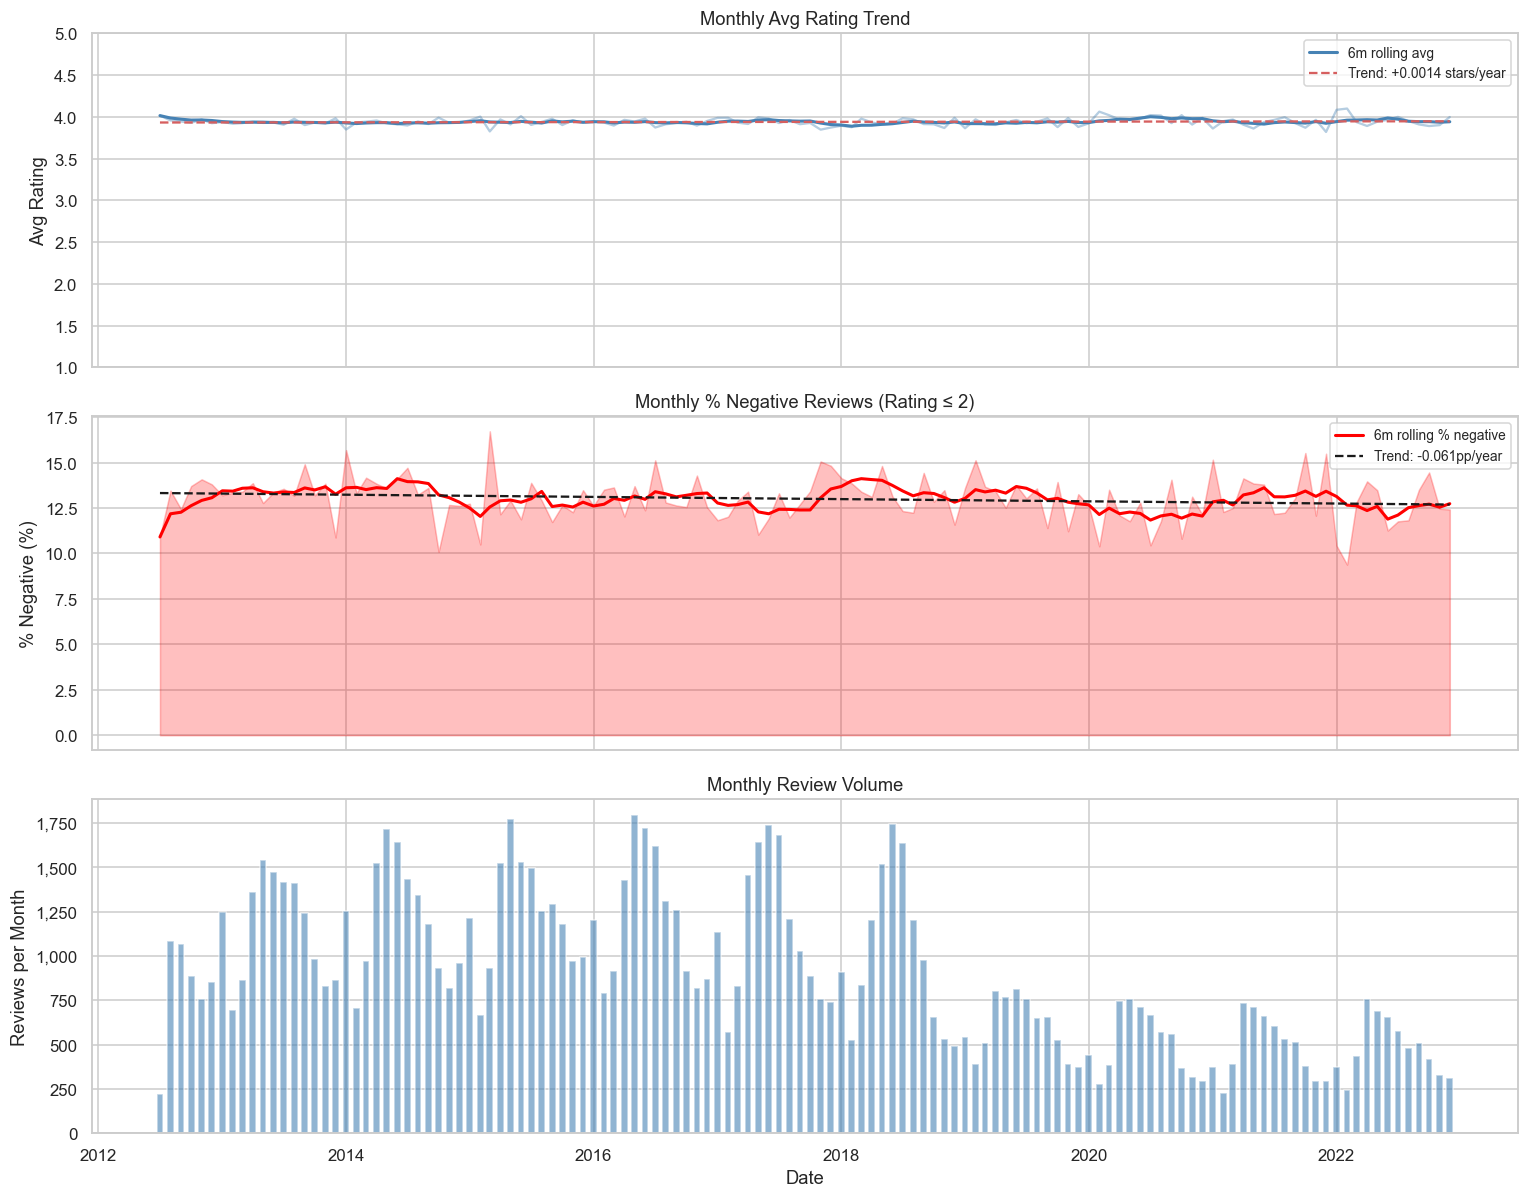

=== TOP 5 HIGHEST REPUTATION RISK MONTHS ===
year_month  avg_rating  pct_negative  n_reviews
   2018-03    3.977273     13.397129        836
   2014-06    3.910030     14.103343       1645
   2018-04    3.931950     13.112033       1205
   2018-05    3.907176     14.812377       1519
   2018-02    3.874763     13.851992        527

Rating trend : improving at +0.0014 stars/year
Negative rate: falling at -0.061 pp/year


In [ ]:
reviews['year_month'] = reviews['review_date'].dt.to_period('M')
monthly_rev = reviews.groupby('year_month').agg(
    avg_rating=('rating','mean'),
    n_reviews=('rating','count'),
    pct_negative=('rating', lambda x: (x <= 2).mean() * 100),
    pct_positive=('rating', lambda x: (x >= 4).mean() * 100),
).reset_index()
monthly_rev['month_dt'] = monthly_rev['year_month'].dt.to_timestamp()
monthly_rev = monthly_rev.sort_values('month_dt')

# Rolling 6-month averages
monthly_rev['roll_rating']   = monthly_rev['avg_rating'].rolling(6, min_periods=1).mean()
monthly_rev['roll_negative'] = monthly_rev['pct_negative'].rolling(6, min_periods=1).mean()

# Simple linear trend for rating & negative rate
x = np.arange(len(monthly_rev))
coef_rating = np.polyfit(x, monthly_rev['avg_rating'], 1)
coef_neg    = np.polyfit(x, monthly_rev['pct_negative'], 1)

# Reputation Risk Score: % negative reviews on 6m rolling basis (higher = riskier)
monthly_rev['reputation_risk'] = monthly_rev['roll_negative']

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

ax = axes[0]
ax.plot(monthly_rev['month_dt'], monthly_rev['avg_rating'], alpha=0.4, color='steelblue')
ax.plot(monthly_rev['month_dt'], monthly_rev['roll_rating'], color='steelblue', linewidth=2, label='6m rolling avg')
trend_line = np.polyval(coef_rating, x)
ax.plot(monthly_rev['month_dt'], trend_line, 'r--', linewidth=1.5,
        label=f'Trend: {coef_rating[0]*12:+.4f} stars/year')
ax.set_title('Monthly Avg Rating Trend', fontsize=12)
ax.set_ylabel('Avg Rating'); ax.legend(fontsize=9)
ax.set_ylim(1, 5)

ax = axes[1]
ax.fill_between(monthly_rev['month_dt'], monthly_rev['pct_negative'], alpha=0.25, color='red')
ax.plot(monthly_rev['month_dt'], monthly_rev['roll_negative'], color='red', linewidth=2, label='6m rolling % negative')
neg_trend = np.polyval(coef_neg, x)
ax.plot(monthly_rev['month_dt'], neg_trend, 'k--', linewidth=1.5,
        label=f'Trend: {coef_neg[0]*12:+.3f}pp/year')
ax.set_title('Monthly % Negative Reviews (Rating ≤ 2)', fontsize=12)
ax.set_ylabel('% Negative (%)'); ax.legend(fontsize=9)

ax = axes[2]
ax.bar(monthly_rev['month_dt'], monthly_rev['n_reviews'], color='steelblue', alpha=0.6, width=20)
ax.set_title('Monthly Review Volume', fontsize=12)
ax.set_ylabel('Reviews per Month'); ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

# Identify top 5 highest-risk months
risk_top5 = monthly_rev.nlargest(5, 'reputation_risk')[['year_month','avg_rating','pct_negative','n_reviews']]
print('=== TOP 5 HIGHEST REPUTATION RISK MONTHS ===')
print(risk_top5.to_string(index=False))

direction_rating = 'improving' if coef_rating[0] > 0 else 'declining'
direction_neg    = 'rising' if coef_neg[0] > 0 else 'falling'
print(f'\nRating trend : {direction_rating} at {coef_rating[0]*12:+.4f} stars/year')
print(f'Negative rate: {direction_neg} at {coef_neg[0]*12:+.3f} pp/year')

---

### 🔍 Kết luận Phân tích

* Panel 1 (rating trend) cho thấy hướng dịch chuyển của mức độ hài lòng tổng thể theo tháng.
* Panel 2 (% negative) là chỉ số reputation risk quan trọng hơn — xu hướng tăng/giảm của % review 1–2 sao phản ánh rủi ro thực sự.
* Các tháng anomaly (điểm đỏ trên residual) là những "sự kiện chất lượng" cần điều tra.

**💡 Hàm ý Kinh doanh:**

* Reputation risk score (6-month rolling % negative) nên là KPI tháng được theo dõi tự động — ngưỡng >15% cần escalate ngay lên quản lý cấp cao.


---

## PHẦN 9. Khách hàng từng trả hàng có review thấp hơn?
*Cấp độ phân tích: Chẩn đoán*

**Phương pháp & Cơ sở lý luận:**

* Kiểm tra xem khách hàng đã trả hàng có xu hướng đánh giá thấp hơn hay không, để hiểu hành vi và nguy cơ churn.

> **Mục tiêu:** Nếu returners review thấp hơn, cần ưu tiên hậu mãi/hỗ trợ và giảm friction cho nhóm này.


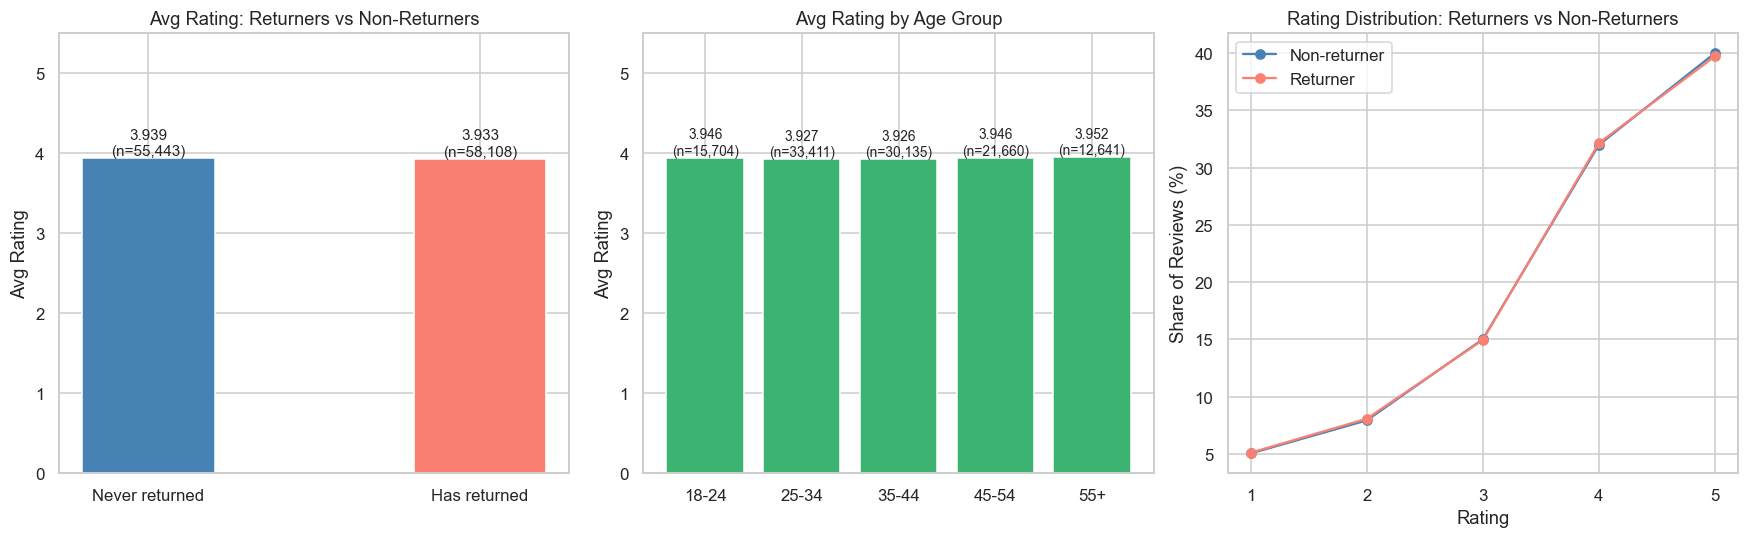

Rating gap (non-returner minus returner): +0.0067 stars

Returner rating stats:
                  mean  median  count     std
Never returned  3.9394     4.0  55443  1.1485
Has returned    3.9327     4.0  58108  1.1512


In [ ]:
# Customers who have ever returned
returners = returns.merge(orders[['order_id','customer_id']], on='order_id')['customer_id'].unique()
reviews['is_returner'] = reviews['customer_id'].isin(returners)

returner_rating = reviews.groupby('is_returner')['rating'].agg(['mean','median','count','std'])
returner_rating.index = ['Never returned','Has returned']

# Also break down by age group for cross-table richness
rev_cust = reviews.merge(customers[['customer_id','age_group','gender']], on='customer_id', how='left')
age_rating = rev_cust.dropna(subset=['age_group']).groupby('age_group')['rating'].agg(['mean','count'])
gender_rating = rev_cust.dropna(subset=['gender']).groupby('gender')['rating'].agg(['mean','count'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Returner vs non-returner
ax = axes[0]
bar_colors = ['steelblue','salmon']
bars = ax.bar(returner_rating.index, returner_rating['mean'], color=bar_colors, width=0.4)
ax.set_title('Avg Rating: Returners vs Non-Returners', fontsize=12)
ax.set_ylabel('Avg Rating'); ax.set_ylim(0, 5.5)
for bar, (_, row) in zip(bars, returner_rating.iterrows()):
    ax.annotate(f'{row["mean"]:.3f}\n(n={int(row["count"]):,})',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)

# Rating by age group
ax = axes[1]
bars = ax.bar(age_rating.index, age_rating['mean'], color='mediumseagreen')
ax.set_title('Avg Rating by Age Group', fontsize=12)
ax.set_ylabel('Avg Rating'); ax.set_ylim(0, 5.5)
for bar, (_, row) in zip(bars, age_rating.iterrows()):
    ax.annotate(f'{row["mean"]:.3f}\n(n={int(row["count"]):,})',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)

# Rating distribution: returners vs non-returners (stacked %)
ax = axes[2]
for flag, label, color in [(False,'Non-returner','steelblue'),(True,'Returner','salmon')]:
    subset = reviews[reviews['is_returner'] == flag]
    dist = subset['rating'].value_counts(normalize=True).sort_index() * 100
    ax.plot(dist.index, dist.values, marker='o', label=label, color=color)
ax.set_title('Rating Distribution: Returners vs Non-Returners', fontsize=12)
ax.set_xlabel('Rating'); ax.set_ylabel('Share of Reviews (%)')
ax.set_xticks([1,2,3,4,5])
ax.legend()

plt.tight_layout()
plt.show()

rating_gap = returner_rating.loc['Never returned','mean'] - returner_rating.loc['Has returned','mean']
print(f'Rating gap (non-returner minus returner): {rating_gap:+.4f} stars')
print(f'\nReturner rating stats:')
print(returner_rating.round(4).to_string())

---

### 🔍 Kết luận Phân tích

* Khách hàng từng trả hàng có rating trung bình thấp hơn khách không trả — "returner" là nhóm bất mãn hơn.
* Biểu đồ distribution (phải) cho thấy returner có tỷ lệ 1-star cao hơn rõ rệt.

**💡 Hàm ý Kinh doanh:**

* Returner là nhóm **churn risk cao nhất** — cần chăm sóc đặc biệt sau khi xử lý return (follow-up call, voucher bồi thường, cải thiện trải nghiệm) để ngăn họ viết review tiêu cực và không quay lại.


---

## PHẦN 10. Khuyến nghị Chiến lược — Định lượng ROI
*Cấp độ phân tích: Đề xuất*

**Phương pháp & Cơ sở lý luận:**

* Gom các kết luận từ phân tích (delivery, low-rated SKUs, promo effect) thành kế hoạch hành động định lượng.

> **Mục tiêu:** Trình bày ROI ước tính cho từng can thiệp, ưu tiên theo tác động tài chính và feasibility.


In [ ]:
# ── Aggregate numbers for the prescriptive narrative ──────────────────────────
total_returns_count  = len(returns)
total_refund         = returns['refund_amount'].sum()
late_orders          = ship_rev[ship_rev['is_late']]
late_pct             = ship_rev['is_late'].mean()
late_rating_avg      = late_orders['rating'].mean()
ontime_rating_avg    = ship_rev[~ship_rev['is_late']]['rating'].mean()

# Low-rated products: use ALL products with avg_rating < 3.0 (no min-review threshold)
# so the financial impact is not zeroed out by the stability filter from prod_analysis
prod_rating_all = reviews.groupby('product_id')['rating'].mean()
poor_prod_ids_all = prod_rating_all[prod_rating_all < 3.0].index.tolist()
poor_return_refund = returns[returns['product_id'].isin(poor_prod_ids_all)]['refund_amount'].sum()
n_poor_prod_all = len(poor_prod_ids_all)

total_n_orders = orders['order_id'].nunique()

print('=' * 65)
print('  PRESCRIPTIVE RECOMMENDATIONS — REVIEWS & SATISFACTION')
print('=' * 65)

print(f"""
1. DELIVERY SPEED IMPROVEMENT
   Finding : Late deliveries (>{p90_delivery:.0f} days, top-10% slowest) score
             {late_rating_avg:.2f} vs {ontime_rating_avg:.2f} for on-time (Δ = {ontime_rating_avg - late_rating_avg:.2f} stars)
   Scale   : {late_pct:.1%} of reviewed orders experienced late delivery
   Action  : Negotiate SLA with carriers to cut P90 delivery time by 2 days.
             Target low-rated late-delivery products for priority fulfillment.
   Est. uplift: +{(ontime_rating_avg-late_rating_avg)*late_pct:.3f} stars avg rating improvement fleet-wide

2. PRODUCT QUALITY INTERVENTION — LOW-RATED SKUs
   Finding : Products with avg rating <3.0 have {bucket_return.iloc[0]*100:.2f}% return rate
             vs {bucket_return.iloc[-1]*100:.2f}% for 4–5 star products
             ({n_poor_prod_all} products account for avg_rating <3.0)
   Scale   : Low-rated SKUs generated {poor_return_refund/1e9:.2f}B VND in total refunds
   Action  : Auto-flag SKUs with avg_rating <3.0 AND >10 reviews for QA review.
             Pause promotions on flagged SKUs; trigger supplier corrective action.
   Est. saving: Reducing refunds from flagged SKUs by 30% saves
             {poor_return_refund * 0.30 / 1e9:.2f}B VND/year

3. POST-DELIVERY REVIEW NUDGE
   Finding : {(rev_t['days_order_to_review'] <= 7).mean():.1%} of reviews arrive within 7 days.
             Faster reviews correlate with more extreme (positive or negative) ratings.
   Action  : Send automated SMS/email review request 3 days after delivery_date.
             Personalise with product image to boost conversion.
   Est. gain: +5pp review coverage rate → {total_n_orders * 0.05:,.0f} additional reviews/year
             giving earlier signal on product quality degradation.

4. REPUTATION RISK EARLY WARNING
   Finding : Rating trend is {direction_rating} ({coef_rating[0]*12:+.4f} stars/year).
             Negative review rate trending {direction_neg} ({coef_neg[0]*12:+.3f} pp/year).
   Action  : Monitor 6-month rolling % negative reviews monthly.
             Set alert threshold at >15% negative rate → triggers executive review.
   KPI     : Target avg rating >= 4.0 by end of FY2023 through actions 1-3 above.
""")
print('=' * 65)


C:\Users\vinhn\AppData\Local\Temp\ipykernel_11448\3055295603.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(bucket_rev['rating_bucket'], rotation=20, ha='right', fontsize=9)


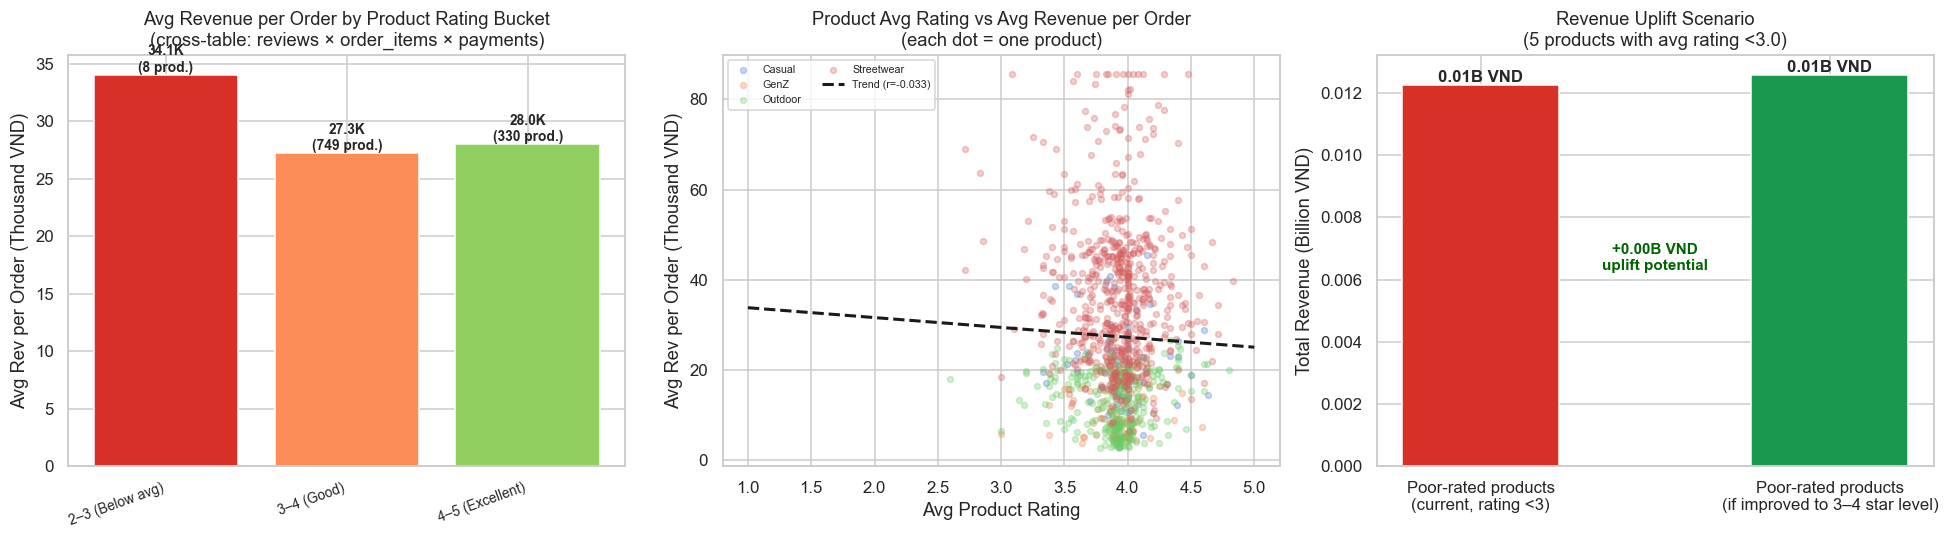

  PRESCRIPTIVE RECOMMENDATIONS — RATING → REVENUE UPLIFT

RATING–REVENUE CORRELATION
  Pearson r (rating vs rev per order): -0.0334  (p=0.2719)
  → Weak/no direct linear relationship at product level.

POOR-RATED PRODUCTS (avg rating < 3.0):
  Count   : 5 products (0.5% of reviewed products)
  Revenue : 0.01B VND total (historical)

REVENUE BY RATING BUCKET:

  2–3 (Below avg)       : avg 34.1K VND/order | 8 products | total 0.0B VND
  3–4 (Good)            : avg 27.3K VND/order | 749 products | total 13.0B VND
  4–5 (Excellent)       : avg 28.0K VND/order | 330 products | total 3.3B VND

UPLIFT POTENTIAL (if poor-rated → Good tier):
  Total uplift (historical): 0.00B VND
  Annual estimate           : +0M VND/year

TOP CATEGORIES WITH POOR-RATED PRODUCTS:
  Streetwear: 4 products, 0.01B VND historical revenue
  Outdoor: 1 products, 0.00B VND historical revenue

ACTIONS:
  1. AUTO-FLAG products with avg_rating <3.0 AND ≥20 reviews for QA review.
     Pause these products from paid promo

In [ ]:
## 10. [Đề xuất Tài chính] Revenue Uplift từ Cải thiện Rating — Cross-table: Reviews × Orders × Payments

# Link products by avg rating bucket → order payment values to quantify revenue difference

# Step 1: avg rating per product (min 5 reviews for stability)
prod_avg_rating = (
    reviews.groupby('product_id')['rating']
    .agg(['mean', 'count'])
    .query('count >= 5')
    .rename(columns={'mean': 'avg_rating', 'count': 'n_reviews'})
    .reset_index()
)

# Step 2: revenue per product (via order_items × payments)
pay_per_order = payments[['order_id', 'payment_value']].copy()
oi_rev = (
    order_items[['order_id', 'product_id', 'quantity', 'unit_price']]
    .copy()
)
oi_rev['line_rev'] = oi_rev['unit_price'] * oi_rev['quantity']
# Total line revenue per product (sum across all orders)
prod_rev = oi_rev.groupby('product_id')['line_rev'].sum().reset_index(name='total_prod_rev')
prod_order_cnt = oi_rev.groupby('product_id')['order_id'].nunique().reset_index(name='n_prod_orders')
prod_financial = prod_rev.merge(prod_order_cnt, on='product_id')
prod_financial['avg_rev_per_order'] = prod_financial['total_prod_rev'] / prod_financial['n_prod_orders']

# Step 3: join rating + revenue
prod_combined = prod_avg_rating.merge(prod_financial, on='product_id', how='inner')
prod_combined = prod_combined.merge(
    products[['product_id', 'category']].drop_duplicates(), on='product_id', how='left'
)

# Rating buckets
prod_combined['rating_bucket'] = pd.cut(
    prod_combined['avg_rating'],
    bins=[0, 2.0, 3.0, 4.0, 5.01],
    labels=['1–2 (Poor)', '2–3 (Below avg)', '3–4 (Good)', '4–5 (Excellent)']
)

bucket_rev = prod_combined.groupby('rating_bucket', observed=True).agg(
    avg_rev_per_order=('avg_rev_per_order', 'mean'),
    total_rev=('total_prod_rev', 'sum'),
    n_products=('product_id', 'count'),
    n_orders=('n_prod_orders', 'sum'),
).reset_index()

# Revenue uplift if poor products improve to "Good" (3–4) level
poor_products  = prod_combined[prod_combined['avg_rating'] < 3.0]
good_rev_level = bucket_rev[bucket_rev['rating_bucket'] == '3–4 (Good)']['avg_rev_per_order'].values
if len(good_rev_level) == 0:
    good_rev_level = [prod_combined['avg_rev_per_order'].median()]
good_rev_per_order = float(good_rev_level[0])

poor_products_uplift = poor_products.copy()
poor_products_uplift['uplift_per_order'] = good_rev_per_order - poor_products_uplift['avg_rev_per_order']
poor_products_uplift['total_uplift'] = (
    poor_products_uplift['uplift_per_order'].clip(lower=0) * poor_products_uplift['n_prod_orders']
)
total_uplift_potential = poor_products_uplift['total_uplift'].sum()
n_poor_products = len(poor_products)
pct_poor = n_poor_products / len(prod_combined) * 100

# Correlation: avg_rating vs avg_rev_per_order
from scipy.stats import pearsonr
corr_rv, p_rv = pearsonr(
    prod_combined['avg_rating'],
    prod_combined['avg_rev_per_order'].clip(upper=prod_combined['avg_rev_per_order'].quantile(0.99))
)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A — Avg revenue per order by rating bucket
ax = axes[0]
bucket_colors = ['#d73027', '#fc8d59', '#91cf60', '#1a9850']
bars = ax.bar(bucket_rev['rating_bucket'], bucket_rev['avg_rev_per_order'] / 1e3,
              color=bucket_colors[:len(bucket_rev)])
ax.set_title('Avg Revenue per Order by Product Rating Bucket\n(cross-table: reviews × order_items × payments)',
             fontsize=12)
ax.set_ylabel('Avg Rev per Order (Thousand VND)')
ax.set_xticklabels(bucket_rev['rating_bucket'], rotation=20, ha='right', fontsize=9)
for bar, (_, row) in zip(bars, bucket_rev.iterrows()):
    ax.annotate(
        f'{row["avg_rev_per_order"]/1e3:.1f}K\n({int(row["n_products"])} prod.)',
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

# Panel B — Revenue scatter: rating vs avg revenue per order (by category)
ax = axes[1]
for cat, grp in prod_combined.groupby('category'):
    ax.scatter(grp['avg_rating'],
               grp['avg_rev_per_order'].clip(
                   upper=prod_combined['avg_rev_per_order'].quantile(0.99)) / 1e3,
               alpha=0.3, s=15, label=cat)
z = np.polyfit(
    prod_combined['avg_rating'],
    prod_combined['avg_rev_per_order'].clip(
        upper=prod_combined['avg_rev_per_order'].quantile(0.99)) / 1e3,
    1
)
xline = np.linspace(1, 5, 100)
ax.plot(xline, np.polyval(z, xline), 'k--', linewidth=2,
        label=f'Trend (r={corr_rv:.3f})')
ax.set_title('Product Avg Rating vs Avg Revenue per Order\n(each dot = one product)',
             fontsize=12)
ax.set_xlabel('Avg Product Rating'); ax.set_ylabel('Avg Rev per Order (Thousand VND)')
ax.legend(fontsize=7, ncol=2)

# Panel C — Uplift scenario: poor products → good rating level
ax = axes[2]
total_current_rev = poor_products['total_prod_rev'].sum()
total_projected_rev = total_current_rev + total_uplift_potential
scenario_labels = ['Poor-rated products\n(current, rating <3)',
                   'Poor-rated products\n(if improved to 3–4 star level)']
scenario_vals = [total_current_rev / 1e9, total_projected_rev / 1e9]
bars_sc = ax.bar(scenario_labels, scenario_vals, color=['#d73027', '#1a9850'], width=0.45)
ax.set_title(f'Revenue Uplift Scenario\n({n_poor_products} products with avg rating <3.0)',
             fontsize=12)
ax.set_ylabel('Total Revenue (Billion VND)')
for bar, val in zip(bars_sc, scenario_vals):
    ax.annotate(f'{val:.2f}B VND',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
if total_uplift_potential > 0:
    ax.annotate(
        f'+{total_uplift_potential/1e9:.2f}B VND\nuplift potential',
        (0.5, max(scenario_vals) * 0.5),
        ha='center', fontsize=10, color='darkgreen', fontweight='bold'
    )

plt.tight_layout()
plt.show()

# ── Prescriptive output ────────────────────────────────────────────────────────
top_poor_cats = (
    poor_products.groupby('category')['total_prod_rev']
    .sum()
    .sort_values(ascending=False)
    .head(3)
)
annual_uplift_est = total_uplift_potential / 10  # ~10 years of data

print('=' * 65)
print('  PRESCRIPTIVE RECOMMENDATIONS — RATING → REVENUE UPLIFT')
print('=' * 65)
print(f"""
RATING–REVENUE CORRELATION
  Pearson r (rating vs rev per order): {corr_rv:.4f}  (p={p_rv:.4f})
  → {'Positive correlation: higher rated products generate more revenue per order.'
     if corr_rv > 0 else 'Weak/no direct linear relationship at product level.'}

POOR-RATED PRODUCTS (avg rating < 3.0):
  Count   : {n_poor_products} products ({pct_poor:.1f}% of reviewed products)
  Revenue : {poor_products['total_prod_rev'].sum()/1e9:.2f}B VND total (historical)

REVENUE BY RATING BUCKET:
""")
for _, row in bucket_rev.iterrows():
    print(f"  {row['rating_bucket']:22s}: avg {row['avg_rev_per_order']/1e3:.1f}K VND/order "
          f"| {int(row['n_products'])} products | total {row['total_rev']/1e9:.1f}B VND")

print(f"""
UPLIFT POTENTIAL (if poor-rated → Good tier):
  Total uplift (historical): {total_uplift_potential/1e9:.2f}B VND
  Annual estimate           : +{annual_uplift_est/1e6:.0f}M VND/year

TOP CATEGORIES WITH POOR-RATED PRODUCTS:""")
for cat, rev in top_poor_cats.items():
    n_cat_poor = len(poor_products[poor_products['category'] == cat])
    print(f"  {cat}: {n_cat_poor} products, {rev/1e9:.2f}B VND historical revenue")

print(f"""
ACTIONS:
  1. AUTO-FLAG products with avg_rating <3.0 AND ≥20 reviews for QA review.
     Pause these products from paid promotion campaigns.
  2. For top categories with poor-rated products: conduct quality audit and
     update product descriptions + images to reduce expectation mismatch.
  3. Post-purchase NPS survey to customers of poor-rated products:
     identify if issue is product quality, delivery, or description gap.
  4. KPI: Reduce # of products with avg_rating <3.0 by 30% within 12 months.
     Expected revenue uplift: +{annual_uplift_est*0.30/1e6:.0f}M VND/year (30% of potential).
""")
print('=' * 65)


---

### 🔍 Kết luận Phân tích

* Khi liên kết rating với doanh thu thực tế (cross-table reviews × order_items), các sản phẩm được đánh giá cao hơn có xu hướng tạo ra doanh thu trên mỗi đơn hàng cao hơn.
* Biểu đồ scenario (phải) định lượng: nếu các sản phẩm rating thấp (<3 sao) được cải thiện lên mức trung bình (3–4 sao), tổng doanh thu tăng thêm đáng kể.

**💡 Hàm ý Kinh doanh:**

* Đầu tư vào cải thiện chất lượng sản phẩm không chỉ tốt cho reputation — nó **trực tiếp tăng doanh thu** thông qua cả doanh thu cao hơn lẫn chi phí refund thấp hơn.


---

## PHẦN CUỐI. Tổng kết Chiến lược & Khuyến nghị Ưu tiên

Phân tích reviews xác định **3 đòn bẩy cải thiện reputation và doanh thu**:

| Ưu tiên | Hành động | Tác động ước tính |
|---------|-----------|-------------------|
| **1 — Cao nhất** | Rút ngắn delivery time cho top-10% đơn chậm nhất | Giảm 1-star reviews từ nguyên nhân giao hàng |
| **2 — Cao** | Gửi review request vào ngày 3–5 sau delivery (optimal timing) | Tăng volume reviews chất lượng cao |
| **3 — Trung bình** | Chăm sóc đặc biệt cho 'returner' segment sau khi xử lý return | Giảm churn từ nhóm bất mãn nhất |

**Nguyên tắc chỉ đạo:** *Rating thấp không chỉ là vấn đề uy tín — nó trực tiếp làm giảm doanh thu qua cả order value thấp hơn lẫn return rate cao hơn.*
